# Cervical Cancer Risk Prediction Model

This notebook implements a machine learning pipeline to predict the risk of cervical cancer (specifically `Biopsy` results) based on demographic and medical history data.

## Dataset
The dataset used is `kag_risk_factors_cervical_cancer.csv`.

## Workflow
1. Data Loading & Inspection
2. Data Preprocessing (Handling missing values, types)
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Training (Logistic Regression, Random Forest, XGBoost)
6. Evaluation
7. Model Explainability (SHAP)
8. Threshold Tuning
9. Model Serialization

In [20]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')

## 1. Data Loading

In [21]:
# Load the dataset
# '?' is used as a placeholder for missing values in this dataset
try:
    df = pd.read_csv('kag_risk_factors_cervical_cancer.csv', na_values='?')
    print("Dataset loaded successfully.")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Error: CSV file not found. Please ensure 'kag_risk_factors_cervical_cancer.csv' is in the same directory.")
    pass

df.head()

Dataset loaded successfully.
Shape: (858, 36)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


## 2. Data Preprocessing

In [22]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
print(missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False))

                                    Missing Values  Percentage
STDs: Time since last diagnosis                787   91.724942
STDs: Time since first diagnosis               787   91.724942
IUD                                            117   13.636364
IUD (years)                                    117   13.636364
Hormonal Contraceptives                        108   12.587413
Hormonal Contraceptives (years)                108   12.587413
STDs:vulvo-perineal condylomatosis             105   12.237762
STDs:HPV                                       105   12.237762
STDs:Hepatitis B                               105   12.237762
STDs:HIV                                       105   12.237762
STDs:AIDS                                      105   12.237762
STDs:molluscum contagiosum                     105   12.237762
STDs:genital herpes                            105   12.237762
STDs:pelvic inflammatory disease               105   12.237762
STDs:syphilis                                  105   12

In [23]:
# Drop columns with too many missing values (> 40%)
cols_to_drop = missing_df[missing_df['Percentage'] > 40].index.tolist()
print(f"Dropping columns: {cols_to_drop}")
df = df.drop(columns=cols_to_drop)

# Drop duplicates if any
df = df.drop_duplicates()

Dropping columns: ['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']


In [24]:
# Impute missing values
for col in df.columns:
    if df[col].dtype == 'object' or df[col].nunique() < 5:  # Categorical or low cardinality numeric
        df[col] = df[col].fillna(df[col].mode()[0])
    else:  # Continuous numeric
        df[col] = df[col].fillna(df[col].median())

print("Missing values handled.")

Missing values handled.


In [25]:
# Verify types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 835 entries, 0 to 857
Data columns (total 34 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 835 non-null    int64  
 1   Number of sexual partners           835 non-null    float64
 2   First sexual intercourse            835 non-null    float64
 3   Num of pregnancies                  835 non-null    float64
 4   Smokes                              835 non-null    float64
 5   Smokes (years)                      835 non-null    float64
 6   Smokes (packs/year)                 835 non-null    float64
 7   Hormonal Contraceptives             835 non-null    float64
 8   Hormonal Contraceptives (years)     835 non-null    float64
 9   IUD                                 835 non-null    float64
 10  IUD (years)                         835 non-null    float64
 11  STDs                                835 non-null  

## 3. Exploratory Data Analysis (EDA)

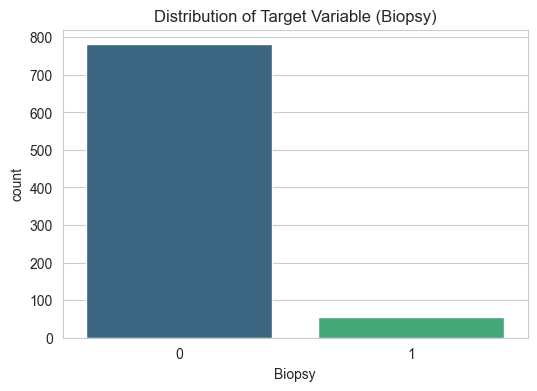

Biopsy
0    0.935329
1    0.064671
Name: proportion, dtype: float64


In [26]:
# Target variable distribution
target = 'Biopsy'

plt.figure(figsize=(6, 4))
sns.countplot(x=target, data=df, palette='viridis')
plt.title('Distribution of Target Variable (Biopsy)')
plt.show()

print(df[target].value_counts(normalize=True))

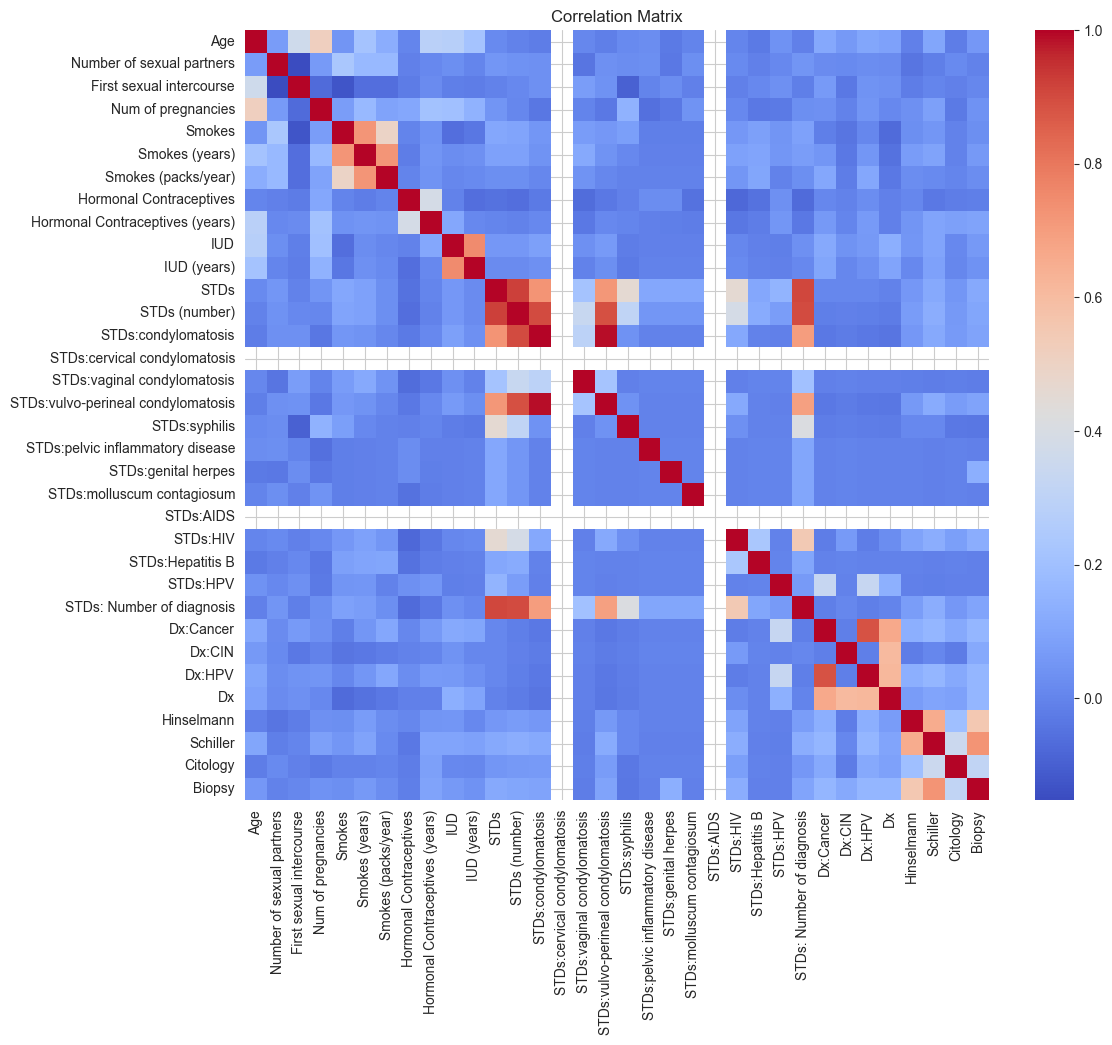

In [27]:
# Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 4. Feature Engineering and Selection

In [28]:
# The dataset has multiple target-like columns: 'Hinselmann', 'Schiller', 'Citology', 'Biopsy'.
# Usually 'Biopsy' is the ground truth diagnosis.
# We should drop the other target proxies to avoid data leakage if predicting Biopsy,
# or keep them if they are considered pre-tests.
# Here we will drop them to rely on risk factors only.

targets_to_drop = ['Hinselmann', 'Schiller', 'Citology']
X = df.drop(columns=[target] + targets_to_drop)
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (668, 30)
Test shape: (167, 30)


In [29]:
# Handling Class Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Resampled Train shape: {X_train_resampled.shape}")
print(f"Class distribution after resampling:\n{y_train_resampled.value_counts()}")

Resampled Train shape: (1250, 30)
Class distribution after resampling:
Biopsy
0    625
1    625
Name: count, dtype: int64


In [30]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

## 5. Model Training

In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)
    
    print(f"--- {name} Results ---")
    print(classification_report(y_test, y_pred))
    
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
    print(f"ROC AUC Score: {roc_auc:.4f}")
    print("-"*30)
    
    results[name] = {
        "model": model,
        "roc_auc": roc_auc,
        "report": classification_report(y_test, y_pred, output_dict=True)
    }

# Select best model based on ROC AUC
best_model_name = max(results, key=lambda k: results[k]['roc_auc'])
best_clf = results[best_model_name]['model']
best_score = results[best_model_name]['roc_auc']

Training Logistic Regression...
--- Logistic Regression Results ---
              precision    recall  f1-score   support

           0       0.96      0.85      0.90       156
           1       0.17      0.45      0.25        11

    accuracy                           0.82       167
   macro avg       0.56      0.65      0.57       167
weighted avg       0.90      0.82      0.86       167

ROC AUC Score: 0.6766
------------------------------
Training Random Forest...
--- Random Forest Results ---
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       156
           1       0.20      0.09      0.12        11

    accuracy                           0.92       167
   macro avg       0.57      0.53      0.54       167
weighted avg       0.89      0.92      0.90       167

ROC AUC Score: 0.5851
------------------------------
Training XGBoost...
--- XGBoost Results ---
              precision    recall  f1-score   support

           0     

## 6. Evaluation of Best Model

Best Model: Logistic Regression with ROC AUC: 0.6766


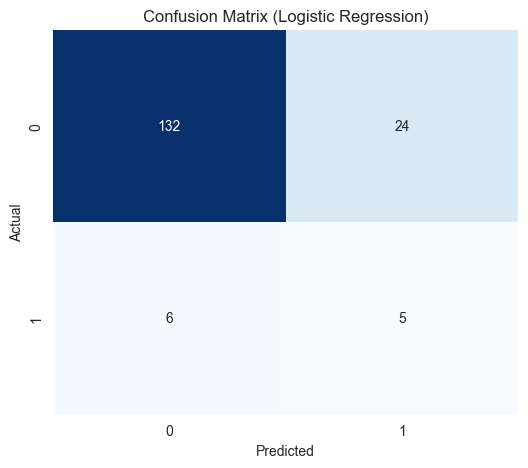

In [32]:
print(f"Best Model: {best_model_name} with ROC AUC: {best_score:.4f}")

# Confusion Matrix for Best Model
y_pred_best = best_clf.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix ({best_model_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [33]:
# Feature Importance (if applicable)
if hasattr(best_clf, 'feature_importances_'):
    importances = best_clf.feature_importances_
    indices = np.argsort(importances)[::-1]
    features = X.columns
    
    plt.figure(figsize=(12, 6))
    plt.title('Feature Importances')
    plt.bar(range(X.shape[1]), importances[indices], align='center')
    plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=90)
    plt.tight_layout()
    plt.show()

## 7. Model Explainability (SHAP)

Explaining model: Logistic Regression


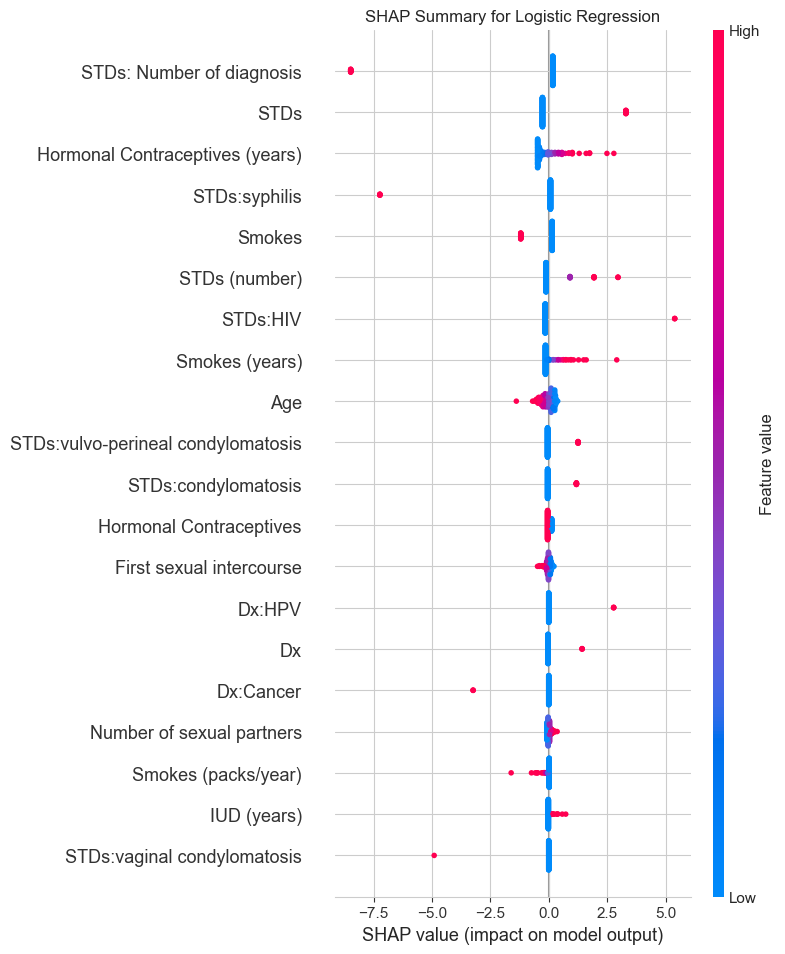

In [34]:
print(f"Explaining model: {best_model_name}")

# SHAP Explainer
if best_model_name in ['Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(best_clf)
    # TreeExplainer usually handles raw model, but here best_clf is trained on scaled data
    shap_values = explainer.shap_values(X_test_scaled)
    
    # Check if shap_values is list (for binary classification, index 1 is positive class)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, show=False)
    plt.title(f'SHAP Summary for {best_model_name}')
    plt.show()
else:
    # Linear models (Logistic Regression)
    # Ensure we pass the model and the background dataset (X_train_scaled)
    explainer = shap.LinearExplainer(best_clf, X_train_scaled)
    shap_values = explainer.shap_values(X_test_scaled)
    
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, show=False)
    plt.title(f'SHAP Summary for {best_model_name}')
    plt.show()

## 8. Threshold Tuning (Optimize for Recall)

In [35]:
from sklearn.metrics import precision_recall_curve

# Get probabilities for positive class
if hasattr(best_clf, "predict_proba"):
    y_scores = best_clf.predict_proba(X_test_scaled)[:, 1]
    
    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
    
    # Find threshold where recall is at least 0.90 (90%)
    desired_recall = 0.90
    valid_indices = np.where(recall[:-1] >= desired_recall)[0]
    
    if len(valid_indices) > 0:
        # Maximize Precision given the recall constraint
        best_idx = valid_indices[np.argmax(precision[valid_indices])]
        optimal_threshold = thresholds[best_idx]
    else:
        optimal_threshold = thresholds[0]
        
    print(f"Optimal Threshold for >{desired_recall*100}% Recall: {optimal_threshold:.4f}")
    
    # Re-evaluate
    y_pred_new = (y_scores >= optimal_threshold).astype(int)
    print("\nReport with Optimized Threshold:")
    print(classification_report(y_test, y_pred_new))
else:
    print("Best model does not support predict_proba, skipping threshold tuning.")

Optimal Threshold for >90.0% Recall: 0.3085

Report with Optimized Threshold:
              precision    recall  f1-score   support

           0       0.98      0.30      0.46       156
           1       0.08      0.91      0.15        11

    accuracy                           0.34       167
   macro avg       0.53      0.61      0.31       167
weighted avg       0.92      0.34      0.44       167



## 9. Save Model

In [36]:
# Save model and scaler
joblib.dump(best_clf, 'cervical_cancer_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved to disk.")

Model and scaler saved to disk.
